In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
logs = pd.read_csv('../log.txt')
logs.columns

Index(['episodes', 'explored_states', 'score'], dtype='str')

In [ ]:
def smoove(x,y, window_size=25):
    ones = np.ones(window_size) / window_size
    new_y = np.convolve(y, ones, mode='valid')
    return x[-new_y.shape[0]:], new_y

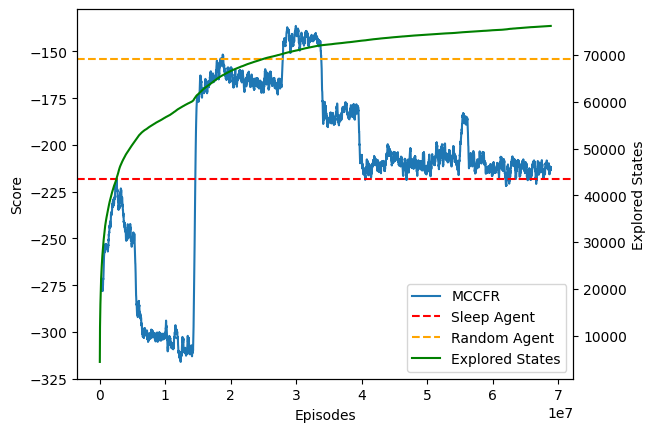

In [7]:
fig,ax = plt.subplots()

x,y = smoove(logs['episodes'], logs['score'])

ln0 = ax.plot(x, y, label='MCCFR')
ax.set_ylabel('Score')
ax.set_xlabel('Episodes')

ln1 = [ax.axhline(y=-218, color='r', linestyle='--', label='Sleep Agent')]
ln2 = [ax.axhline(y=-154, color='orange', linestyle='--', label='Random Agent')]

ax2 = ax.twinx()
ax2.set_ylabel('Explored States')
ln3 = ax2.plot(logs['episodes'], logs['explored_states'], color='green', label='Explored States')

lns = ln0+ln1+ln2+ln3
labs = [l.get_label() for l in lns]
ax2.legend(lns,labs)

plt.show()